In [1]:
import numpy as np
from matplotlib import pyplot as plt
import csv

%matplotlib inline

import xarray as xr
import lib_ecofun as lef
from importlib import reload
reload(lef)
from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct

In [2]:
lef.beta_fun(0, 1, delta_sig= 0.5)

np.float64(0.9772498680518208)

In [ ]:
lef.beta_fun?

# Model tuning

### Setting inicond and obs to fit

In [2]:
fcu = 0.8
inicond = lef.inicond_yr(2000)
inicond['Kf_ini'] = inicond['Kf_ini']*lef.fossil_capacity_util/fcu

obs = dict()
#obs['Ig_ratio'] = lef.Ig_obs/(lef.Ig_obs+lef.If_obs) # considering only investment in power generation capacity (no grids, storage, EVs, ...)
obs['Eg_ratio'] = lef.Eg_ratio

E_obs = xr.load_dataarray('Etot_hist_1965-2022.nc')
E_obs /= E_obs.sel(year = 2000)
obs['E'] = E_obs

### Chose params to fit and bounds (initial guess only needed for minimize)

In [3]:
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'eta_f']
#bounds = [(0.02, 0.03), (-0.3, 0.3), (0.2, 0.6), (0.7, 1.3), (0.7, 1.3), (0.5, 0.9), (0.5, 0.9)]
bounds = [(0.01, 0.03), (-0.5, 0.5), (0.2, 0.8), (0.5, 1.5), (0.5, 1.5), (0.2, 0.9), (0.2, 0.9)]
#initial_guess = [0.2, 0, 0.5, 1., 1., 0.8, 0.8]
initial_guess = [lef.best_params[par] for par in parnames]

param_bounds = {par: boun for par, boun in zip(parnames, bounds)}

# parnames = ['growth', 'beta_0', 'r_inv', 'a', 'delta_sig']
# bounds = [(0.02, 0.03), (-0.3, 0.3), (0.2, 0.6), (0.5, 1.5), (0.3, 2.)]
# initial_guess = [0.02, 0., 0.1, 1., 1., 0.7, 0.7]

In [5]:
initial_guess

[0.0209418049925536,
 -0.2831097084724121,
 0.11684169484450775,
 0.9418414596187906,
 1,
 0.2,
 0.2]

### Set other options: use public inv? what share? what scenario?

In [4]:
year_ini = 2000

params = lef.default_params.copy()
print(params)
print('-------------')
params['delta_sig'] = 0.5
#params['growth'] = 0.029 # fixing Growth!

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, 2100)})

obs_weights = None

{'growth': 0.01, 'eps': 1, 'a': 1, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.1, 'beta_0': 0.2, 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
-------------


In [ ]:
params

### Fit 1: only market

In [ ]:
from time import time

In [ ]:
time()-time()

In [ ]:
# def cost_function(parset, parnames = ['beta_0', 'gamma_g', 'growth', 'delta_sig'], params = default_params.copy(), year_ini = 2015, inicond = inicond_2015, verbose = False, obs = None, public_investment = False, mu_state_scenario = None, linear_gdp = None, obs_weights = None, break_on_scarcity = False)

result_dict = {}

tips = 'hop dual diffev shgo direct brute'.split()
cose = [basinhopping, dual_annealing, differential_evolution, shgo, direct, brute]

# for tip, cos in zip(tips, cose):
#     print(tip, time())
    
#     result = cos(lef.cost_function, bounds = bounds, args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights))

result = basinhopping(lef.cost_function, x0= initial_guess, minimizer_kwargs = {'args': (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen)}, niter = 10)
result_dict['hop'] = result

In [ ]:
result = differential_evolution(lef.cost_function, bounds, args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights))

In [ ]:
result = dual_annealing(lef.cost_function, bounds, args = (parnames, params, year_ini, inicond, verbose, obs, public_investment, mu_scen, obs_weights))

### Check fits

In [5]:
fit_diffevo = [0.0209422,  -0.46078786,  0.64566798,  0.940755,    0.81971502,  0.9, 0.54004475]
fit_dual = [0.02094171, -0.48711167,  0.40855875,  0.92807348,  1.22551021,  0.82826937, 0.32037296]

In [25]:
fit_dual = [0.02094187, -0.40051247,  0.50045883,  0.96259267,  1.45682541,  0.61333459, 0.24142631]
fit_diffevo = np.array("0.02094188 -0.44921257  0.55798115  0.97262679  1.14217381  0.60538417 0.3224694".split()).astype(float)

In [24]:
fit_diffevo

array([ 0.02094188, -0.44921257,  0.55798115,  0.97262679,  1.14217381,
        0.60538417,  0.3224694 ])

In [29]:
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'eta_f']

year_ini = 2000

params = lef.default_params.copy()
params_fit = fit_diffevo
for par, parval in zip(parnames, params_fit):
    params[par] = parval

resu_de = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)

params:  {'growth': np.float64(0.02094188), 'eps': 1, 'a': np.float64(0.97262679), 'b': np.float64(1.14217381), 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': np.float64(0.60538417), 'eta_f': np.float64(0.3224694), 'h_g': 0.5, 'h_f': 0.5, 'r_inv': np.float64(0.55798115), 'beta_0': np.float64(-0.44921257), 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.01     -0.69      0.08      0.92      0.00      0.31      0.00      0.17
params:  {'growth': np.float64(0.02094188), 'eps': 1, 'a': np.float64(0.97262679), 'b': np.float64(1.14217381), 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': np.float64(0.60538417), 'eta_f': np.float64(0.3224694), 'h_g': 0.5, 'h_f': 0.5, 'r_inv': np.float64(0.55798115), 'beta_0': np.float64(-0.44921257), 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.01     -0.66      0.08      0.94      0.00      0.32      0.00      0.18
params:  {'growth': np.float64(0.02094188), 

In [30]:
lef.costfun(resu_de, obs), lef.costfun(resu_best, obs)

(np.float64(0.03982521390158445), np.float64(0.03984388064615374))

In [8]:
best_params = lef.best_params.copy()

In [9]:
best_params

{'growth': 0.0209418049925536,
 'eps': 1,
 'a': 0.9418414596187906,
 'b': 1,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.11684169484450775,
 'beta_0': -0.2831097084724121,
 'delta_sig': 0.47990969261681554,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.01}

In [10]:
resu_best = lef.run_model(inicond = inicond, params = best_params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)

params:  {'growth': 0.0209418049925536, 'eps': 1, 'a': 0.9418414596187906, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169484450775, 'beta_0': -0.2831097084724121, 'delta_sig': 0.47990969261681554, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.44      0.07      0.93      0.01      0.37      0.00      0.04
params:  {'growth': 0.0209418049925536, 'eps': 1, 'a': 0.9418414596187906, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.11684169484450775, 'beta_0': -0.2831097084724121, 'delta_sig': 0.47990969261681554, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.07     -0.42      0.08      0.95      0.01      0.38      0.00      0.04
params:  {'growth': 0.0209418049925536, 'eps': 1, 'a': 0.9418414596187906, 'b': 1, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_

In [97]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fabiano/Research/git/ecodyn/lib_ecofun.py'>

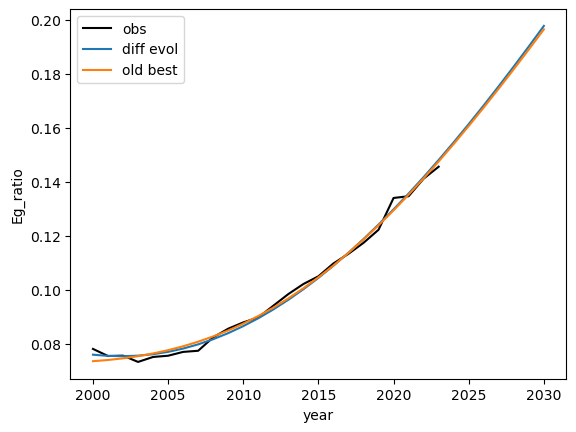

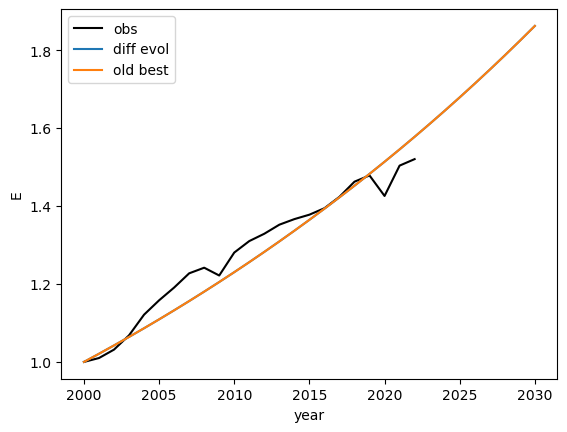

In [31]:
figs_obs = lef.plot_resuvsobs_ds([resu_de, resu_best], obs, run_names=['diff evol', 'old best'])

In [32]:
lef.costfun(resu_de, obs), lef.costfun(resu_best, obs)

(np.float64(0.03982521390158445), np.float64(0.03984388064615374))

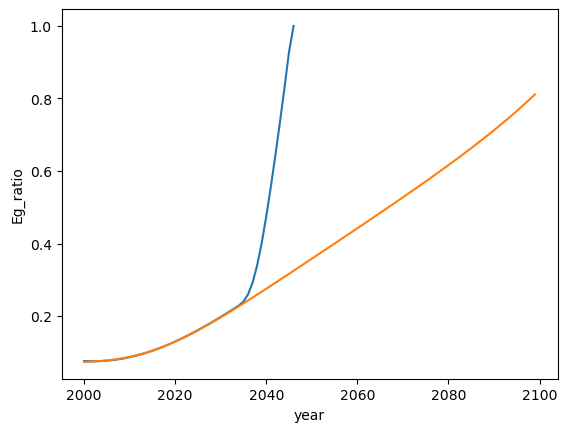

In [33]:
resu_de.Eg_ratio.plot()
resu_best.Eg_ratio.plot()

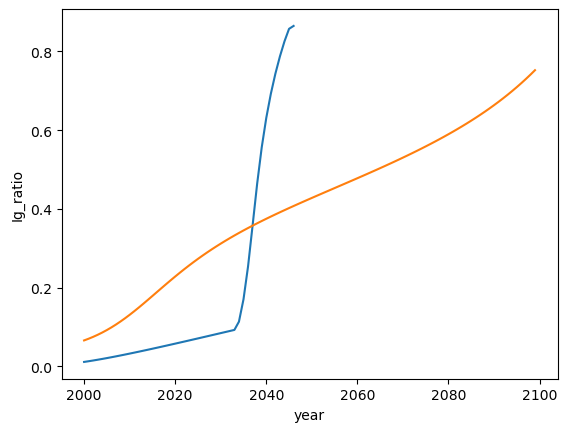

In [34]:
resu_de.Ig_ratio.plot()
resu_best.Ig_ratio.plot()

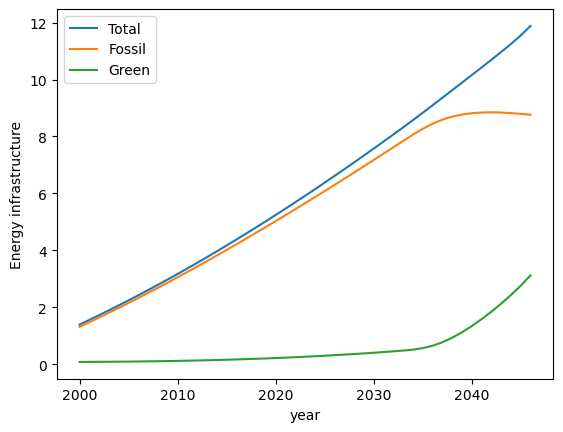

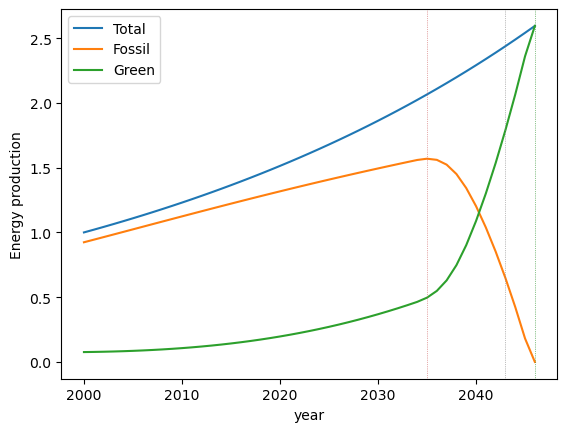

In [36]:
figs_obs = lef.plot_resu(resu_de, obs)

In [37]:
parnames = ['growth', 'beta_0', 'r_inv', 'a', 'b', 'eta_g', 'eta_f']

year_ini = 2000

params = lef.default_params.copy()
params_fit = fit_dual
for par, parval in zip(parnames, params_fit):
    params[par] = parval

resu_dual = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)

params:  {'growth': 0.02094187, 'eps': 1, 'a': 0.96259267, 'b': 1.45682541, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.61333459, 'eta_f': 0.24142631, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.50045883, 'beta_0': -0.40051247, 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.01     -0.72      0.08      0.92      0.00      0.35      0.00      0.17
params:  {'growth': 0.02094187, 'eps': 1, 'a': 0.96259267, 'b': 1.45682541, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.61333459, 'eta_f': 0.24142631, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.50045883, 'beta_0': -0.40051247, 'delta_sig': 0.5, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.01}
check:       0.01     -0.70      0.08      0.94      0.00      0.35      0.00      0.18
params:  {'growth': 0.02094187, 'eps': 1, 'a': 0.96259267, 'b': 1.45682541, 'gamma_f': 0.5, 'gamma_g': 0.5, 'eta_g': 0.61333459, 'eta_f': 0.24142631, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.50045883, 'beta_0': -0.40

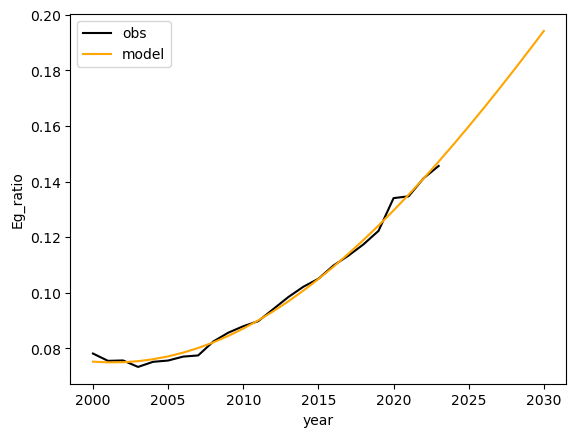

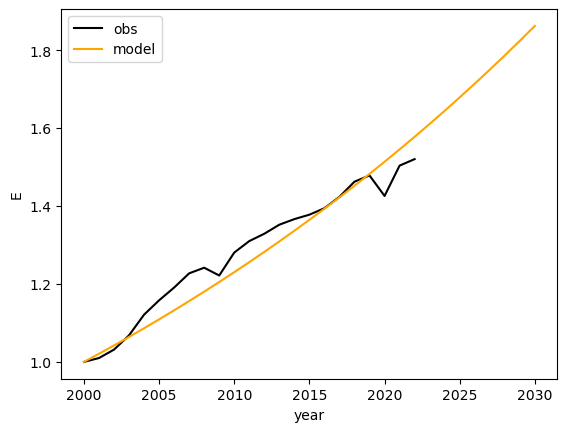

In [38]:
figs_obs = lef.plot_resuvsobs_ds(resu_dual, obs)

In [39]:
lef.costfun(resu_dual, obs), lef.costfun(resu_best, obs)

(np.float64(0.03981947956819211), np.float64(0.03984388064615374))

In [112]:
params

{'growth': 0.02094171,
 'eps': 1,
 'a': 0.92807348,
 'b': 1.22551021,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.82826937,
 'eta_f': 0.32037296,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.40855875,
 'beta_0': -0.48711167,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.01}

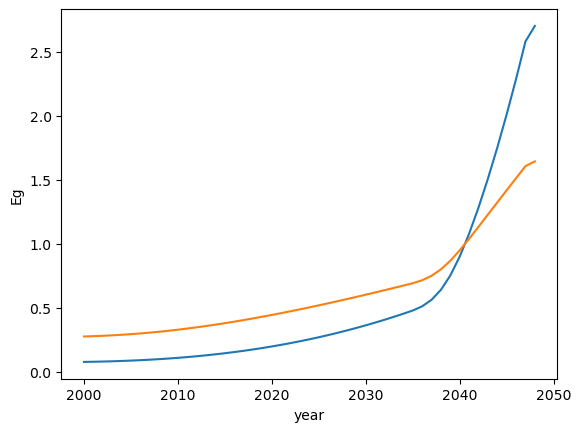

In [54]:
resu_dual.Eg.plot()
(resu_dual.Eg**0.5).plot()

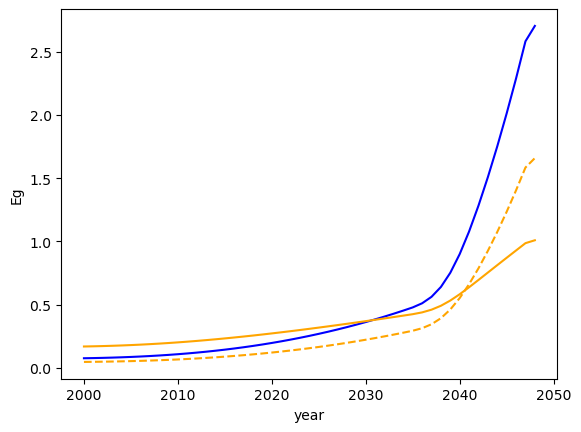

In [41]:
resu_dual.Eg.plot(color = 'blue')
(params['eta_g']*resu_dual.Eg**0.5).plot(color = 'orange')
(params['eta_g']*resu_dual.Eg).plot(color = 'orange', ls = '--')

# Super fit

In [68]:
import re
import numpy as np

def parse_line(line):
    """Parse a line and extract cost and params dict"""
    # Extract cost
    cost_match = re.search(r'Cost:\s+([\d.e+-]+)', line)
    if not cost_match:
        return None, None
    cost = float(cost_match.group(1))
    
    # Extract params dict string
    params_match = re.search(r'params:\s+(\{.+\})', line)
    if not params_match:
        return None, None
    
    params_str = params_match.group(1)
    
    # Convert np.float64(...) to regular floats for eval
    params_str = re.sub(r'np\.float64\(([\d.e+-]+)\)', r'\1', params_str)
    
    # Safely evaluate the dict
    try:
        params = eval(params_str)
        return cost, params
    except:
        return None, None


# def read_costs_from_log(filename):
#     """
#     Read txt file and extract costs and params
    
#     Args:
#         filename: path to txt file
    
#     Returns:
#         costs: list of costs
#         params: list of param dicts
#     """
#     costs = []
#     params = []
    
#     with open(filename, 'r') as f:
#         for line in f:
#             cost, param = parse_line(line)
#             if cost is not None:
#                 costs.append(cost)
#                 params.append(param)
    
#     return costs, params

def read_costs_from_log(filename):
    """
    Read txt file and extract costs and params, segmented by "AAAAAAA" lines
    
    Args:
        filename: path to txt file
    
    Returns:
        all_costs: list of cost lists (one per segment)
        all_params: list of param lists (one per segment)
    """
    all_costs = []
    all_params = []
    
    current_costs = []
    current_params = []
    
    with open(filename, 'r') as f:
        for line in f:
            # Check for segment separator
            if line.strip().startswith("AAAAAAA"):
                # Save current segment if not empty
                if current_costs:
                    all_costs.append(current_costs)
                    all_params.append(current_params)
                # Start new segment
                current_costs = []
                current_params = []
            else:
                # Parse line
                cost, param = parse_line(line)
                if cost is not None:
                    current_costs.append(cost)
                    current_params.append(param)
    
    # Add last segment if not empty
    if current_costs:
        all_costs.append(current_costs)
        all_params.append(current_params)
    
    return all_costs, all_params


def filter_costs(costs, params, percentile=10):
    """
    Filter costs and params by percentile threshold
    
    Args:
        costs: list of costs
        params: list of param dicts
        percentile: keep only entries with cost <= this percentile (default 10)
    
    Returns:
        costs_filtered: list of costs in the percentile
        params_filtered: list of param dicts in the percentile
    """
    # Calculate percentile threshold
    threshold = np.percentile(costs, percentile)
    
    # Filter by percentile
    costs_filtered = []
    params_filtered = []
    
    for cost, param in zip(costs, params):
        if cost <= threshold:
            costs_filtered.append(cost)
            params_filtered.append(param)
    
    return costs_filtered, params_filtered

def filter_by_bounds(costs, params, param_bounds):
    """
    Filter out entries where parameters are outside specified bounds
    
    Args:
        costs: list of costs
        params: list of param dicts
        param_bounds: dict with param names as keys and (min, max) tuples as values
                     Example: {'a': (0.5, 1.0), 'b': (0.0, 2.0)}
    
    Returns:
        costs_filtered: list of costs within bounds
        params_filtered: list of param dicts within bounds
    """
    
    costs_filtered = []
    params_filtered = []
    
    for cost, pardict in zip(costs, params):
        # Check if all params are within bounds
        within_bounds = True
        for par in pardict:
            if par in param_bounds:
                if pardict[par] < param_bounds[par][0] or pardict[par] > param_bounds[par][1]:
                    within_bounds = False
                    break
        
        if within_bounds:
            costs_filtered.append(cost)
            params_filtered.append(pardict)
    
    return costs_filtered, params_filtered

In [43]:
costs, params_all = read_costs_from_log('costs_10novb.txt')

In [60]:
costs_all, params_all_all = read_costs_from_log('log_newfit_10novb.log')

In [62]:
for co in costs_all: print(len(co))

80
174
9347


In [69]:
params

{'growth': 0.020941484099917935,
 'eps': 1,
 'a': 0.9700774731516811,
 'b': 0.9187163631879887,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.713416447548475,
 'eta_f': 0.3946309669285558,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.5568378857496155,
 'beta_0': -0.43588836608785153,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [77]:
# param_bounds = {'growth': (0.01, 0.03),
#  'a': (0.5, 1.5),
#  'b': (0.5, 1.5),
#  'eta_g': (0.2, 0.9),
#  'eta_f': (0.2, 0.9),
#  'r_inv': (0.2, 0.9),
#  'beta_0': (-0.5, 0.5)}

param_bounds = {'growth': (0.0, 0.05),
 'a': (0.1, 5),
 'b': (0.1, 5),
 'eta_g': (0.1, 0.9),
 'eta_f': (0.1, 0.9),
 'r_inv': (0.1, 0.9),
 'beta_0': (-0.5, 0.5)}

In [78]:
costs_hop, params_hop = filter_by_bounds(costs_all[2], params_all_all[2], param_bounds)

In [81]:
costs = costs_all[0] + costs_all[1]
params_all = params_all_all[0] + params_all_all[1] 

In [82]:
len(costs_hop)

808

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 280., 208.,
         16.,   0.,  40.,  24.,  16.,  49.,   8.,  16.,  32.,  57., 168.,
          0.,   0.,   8.,   2.,   1.,   8.,   9.,   1.,   1.,   1.,   0.,
          0.,   0.,   0.,   1.,   1.,   1.,   0.,   1.,   0.,   0.,   7.,
          4.,   0.,   1.,   0.,   9.,   2.]),
 array([0.0398  , 0.039802, 0.039804, 0.039806, 0.039808, 0.03981 ,
        0.039812, 0.039814, 0.039816, 0.039818, 0.03982 , 0.039822,
        0.039824, 0.039826, 0.039828, 0.03983 , 0.039832, 0.039834,
        0.039836, 0.039838, 0.03984 , 0.039842, 0.039844, 0.039846,
        0.039848, 0.03985 , 0.039852, 0.039854, 0.039856, 0.039858,
        0.03986 , 0.039862, 0.039864, 0.039866, 0.039868, 0.03987 ,
        0.039872, 0.039874, 0.039876, 0.039878, 0.03988 , 0.039882,
        0.039884, 0.039886, 0.039888, 0.03989 , 0.039892, 0.039894,
        0.039896, 0.039898, 0.0399  ]),
 <BarContainer object of 50 artists>)

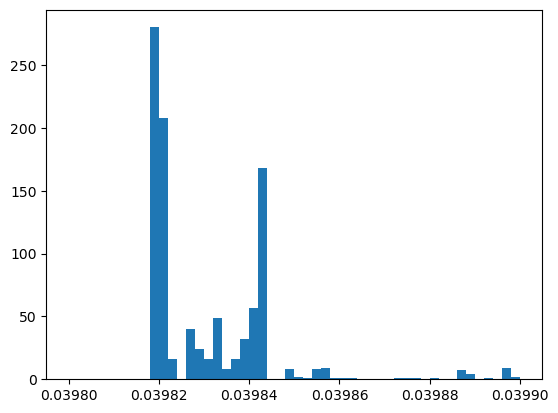

In [80]:
plt.hist(costs+costs_hop, bins = 50, range = (0.0398, 0.0399))

In [65]:
len(costs)

254

In [83]:
year_ini = 2000

resu_all = []

for params in params_all:
    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all.append(resu_x)

In [84]:
resu_all_hop = []
for params in params_hop:
    resu_x = lef.run_model(inicond = inicond, params = params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen)
    resu_all_hop.append(resu_x)

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

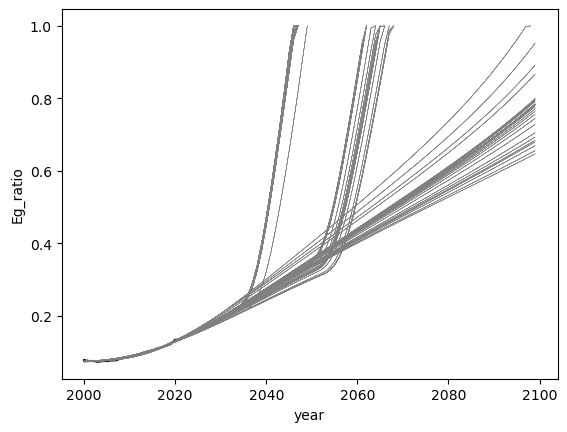

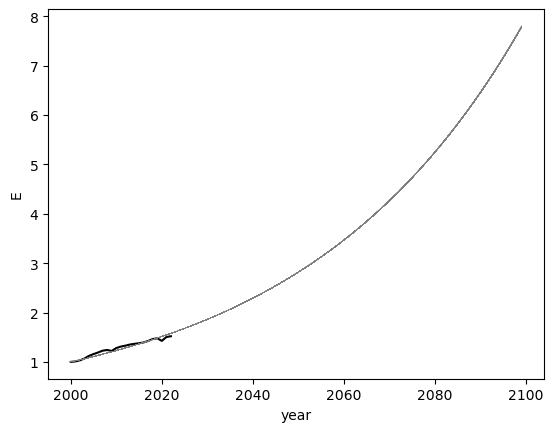

In [85]:
lef.plot_resuvsobs_ds(resu_all_hop, obs, year_ok = slice(2000, 2100), greystyle=True)

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

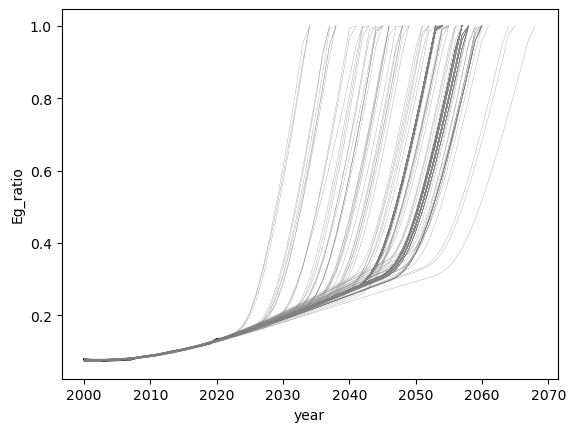

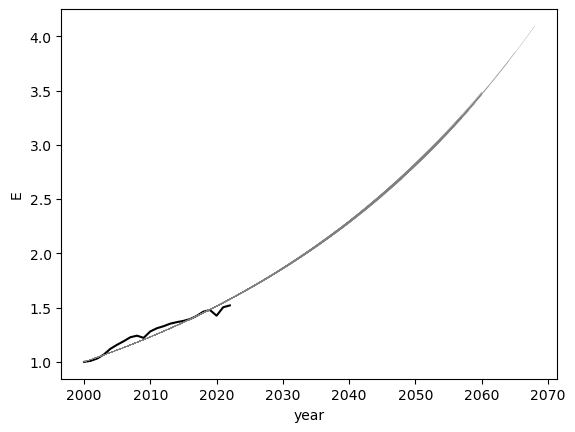

In [67]:
lef.plot_resuvsobs_ds(resu_all, obs, year_ok = slice(2000, 2100), greystyle=True)

In [92]:
type(resu_all_hop)

list

In [95]:
len(resu_all_hop)

808

In [98]:
colors = len(resu_all)*['steelblue'] + len(resu_all_hop)*['orange']

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

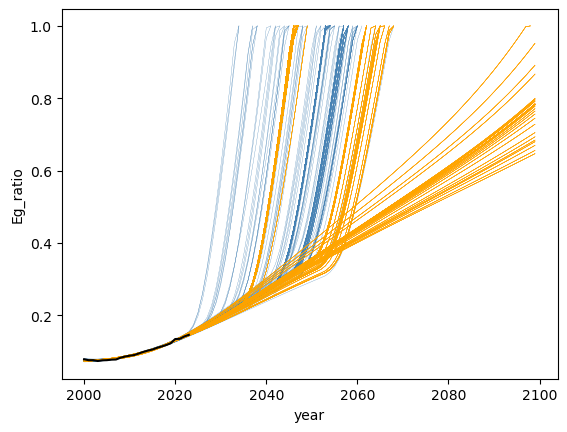

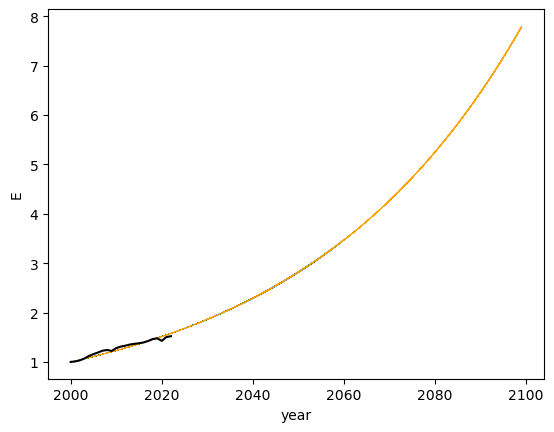

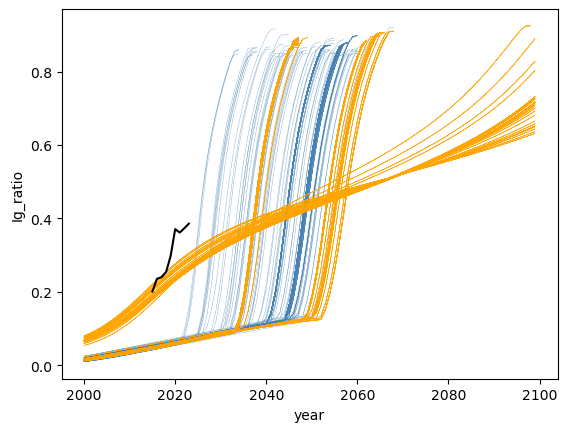

In [101]:
obs_ok = obs.copy()
obs_ok['Ig_ratio'] = lef.Ig_obs/(lef.Ig_obs+lef.If_obs) # considering only investment in power generation capacity (no grids, storage, EVs, ...)
lef.plot_resuvsobs_ds(resu_all + resu_all_hop, obs_ok, year_ok = slice(2000, 2100), greystyle=True, colors = colors)

In [100]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fabiano/Research/git/ecodyn/lib_ecofun.py'>

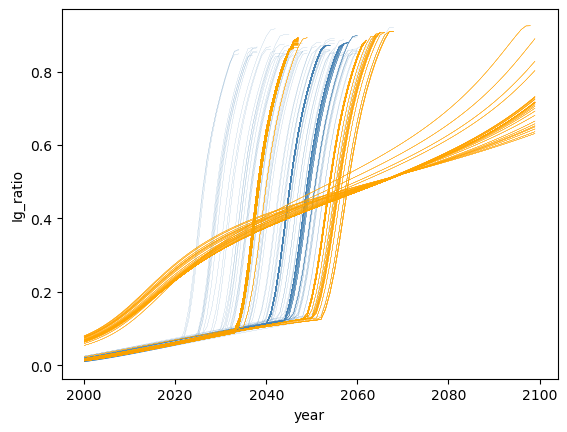

In [88]:
plt.figure()
for res in resu_all:
    res.Ig_ratio.plot(color = 'steelblue', lw = 0.1)

for res in resu_all_hop:
    res.Ig_ratio.plot(color = 'orange', lw = 0.1)

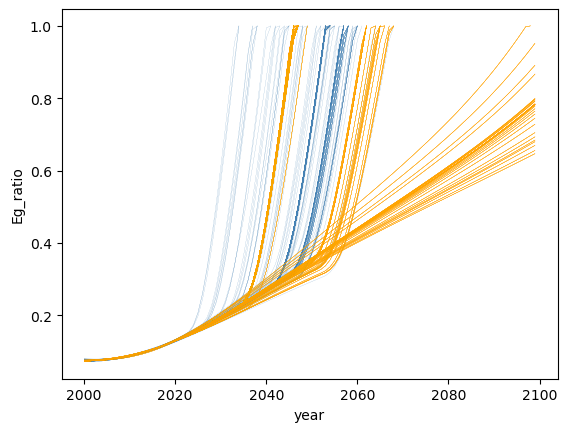

In [89]:
plt.figure()
for res in resu_all:
    res.Eg_ratio.plot(color = 'steelblue', lw = 0.1)

for res in resu_all_hop:
    res.Eg_ratio.plot(color = 'orange', lw = 0.1)

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def plot_param_histograms(params):
    """Plot histogram for each parameter in a multi-panel figure"""
    
    # Get all parameter keys
    param_keys = sorted(set(k for p in params for k in p.keys()))
    
    # Calculate grid dimensions
    n_params = len(param_keys)
    n_cols = int(np.ceil(np.sqrt(n_params)))
    n_rows = int(np.ceil(n_params / n_cols))
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2))
    axes = axes.flatten() if n_params > 1 else [axes]
    
    # Plot each parameter
    for idx, key in enumerate(param_keys):
        values = [p[key] for p in params if key in p]
        axes[idx].hist(values, bins=20, edgecolor='black')
        axes[idx].set_title(key)
        axes[idx].set_ylabel('Count')
    
    # Hide unused subplots
    for idx in range(n_params, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig


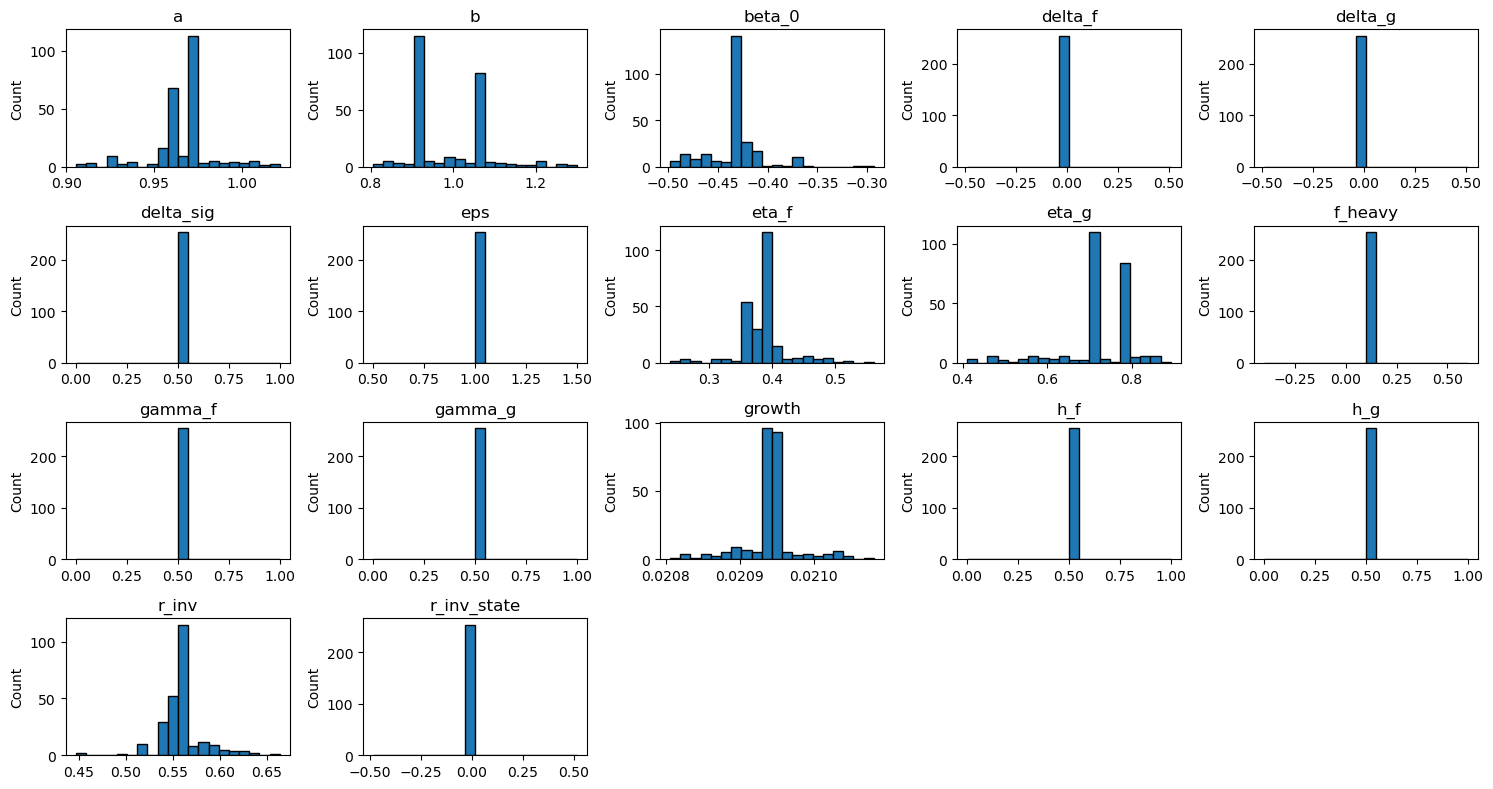

In [86]:
fig = plot_param_histograms(params_all)
plt.show()

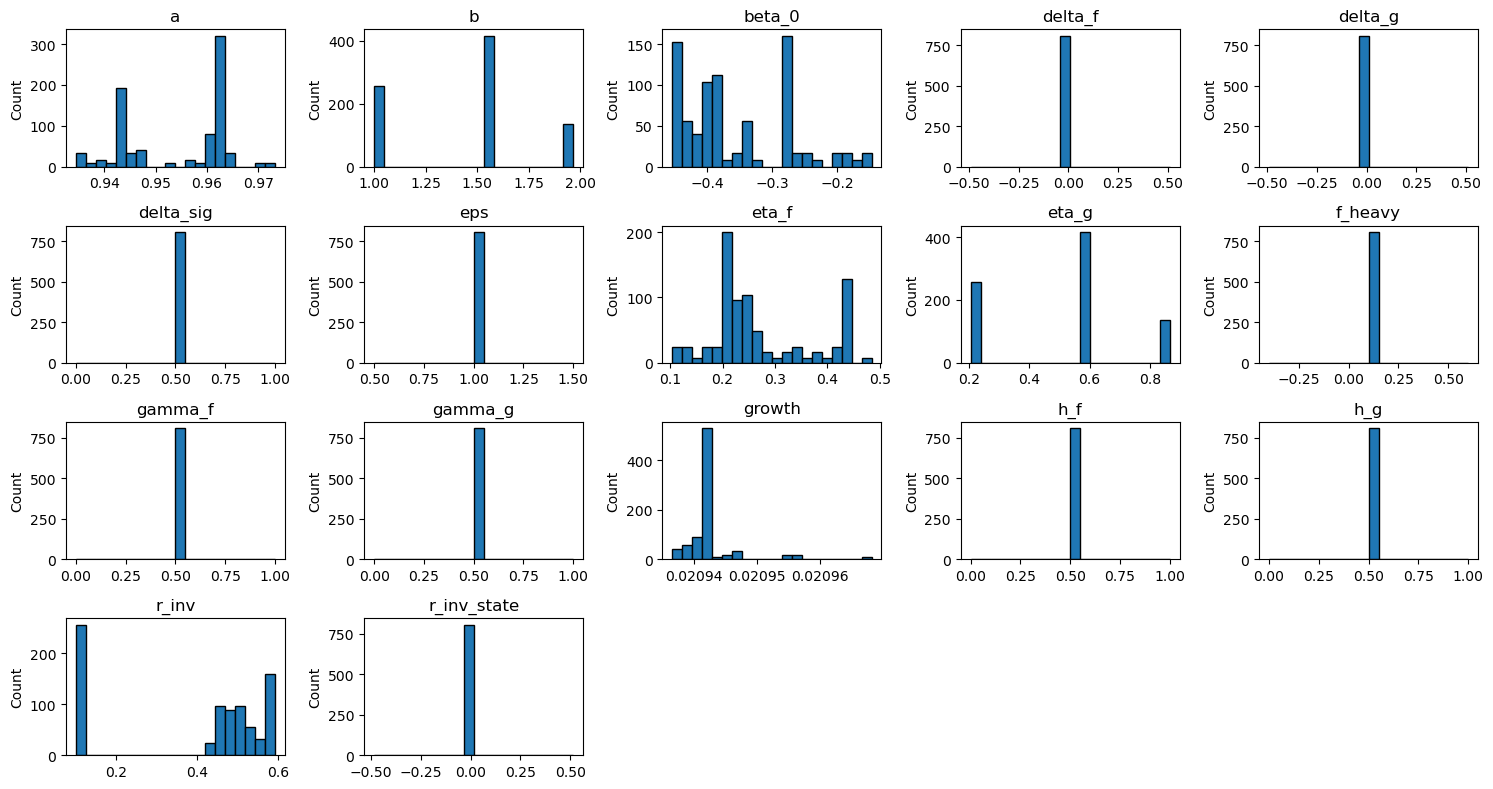

In [87]:
fig = plot_param_histograms(params_hop)

## Now adding investment constraint

# OLD STUFF

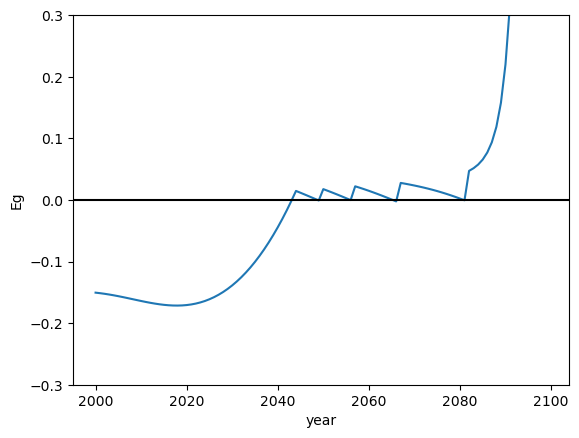

In [118]:
(resu_dual.Eg - params['eta_g']*resu_dual.Eg**0.5).plot()
plt.ylim(-0.3, 0.3)
plt.axhline(0., color = 'black')

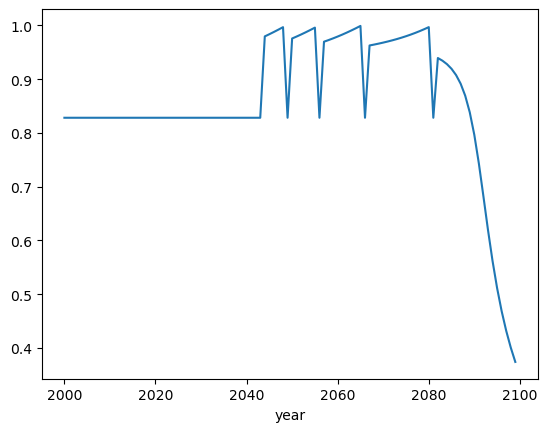

In [113]:
(resu_dual.Cg/resu_dual.Eg).plot()

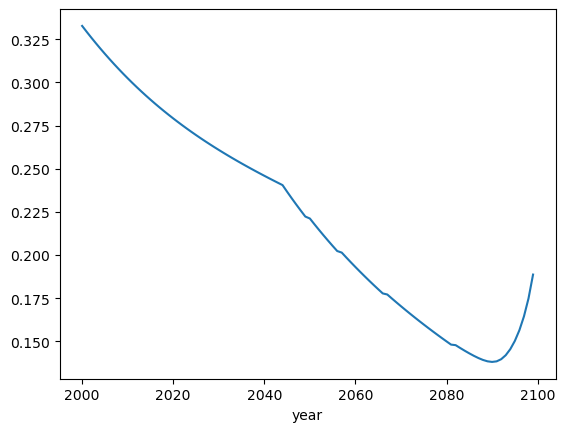

In [114]:
(resu_dual.Cf/resu_dual.Ef).plot()

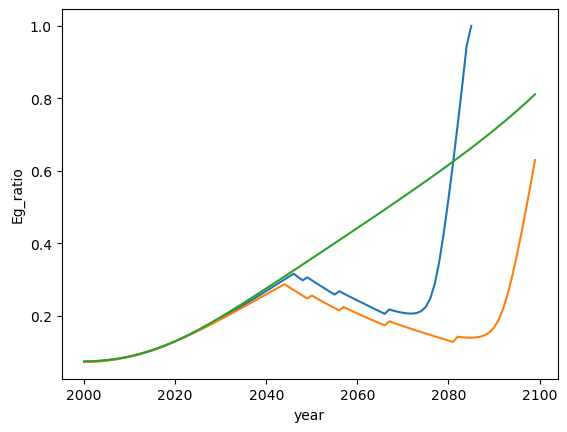

In [102]:
resu_de.Eg_ratio.plot()
resu_dual.Eg_ratio.plot()
resu_best.Eg_ratio.plot()

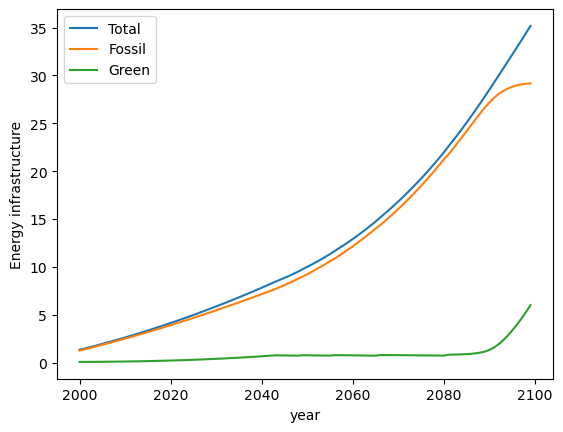

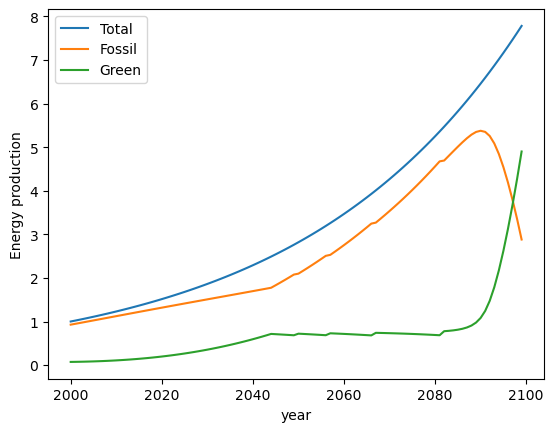

In [103]:
figs_obs = lef.plot_resu(resu_dual, obs)

### Check r_inv and eta

In [ ]:
parnames

In [ ]:
lef.best_params

In [27]:
params

{'growth': 0.0209418049925536,
 'eps': 1,
 'a': 0.9418414596187906,
 'b': 1,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': np.float64(0.8500000000000002),
 'eta_f': np.float64(0.8500000000000002),
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': np.float64(0.8500000000000002),
 'beta_0': -0.2831097084724121,
 'delta_sig': 0.47990969261681554,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.01}

In [45]:
obs_weights

In [50]:
lef.best_params

{'growth': 0.0209418049925536,
 'eps': 1,
 'a': 0.9418414596187906,
 'b': 1,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.11684169484450775,
 'beta_0': -0.2831097084724121,
 'delta_sig': 0.47990969261681554,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.01}

In [57]:
obs_weights = dict()
obs_weights['Eg_ratio'] = 10.
obs_weights['E'] = 1.

params = lef.best_params.copy()
year_ini = 2000
mu_scen = []

vals = np.arange(0.1, 0.95, 0.05)

costs = []
cost_dict = dict()

pars = ['r_inv', 'eta_g', 'eta_f']

for r_inv in vals:
    for eta1 in vals:
        for eta2 in vals:
            vals_ok = (r_inv, eta1, eta2)
            for par, parval in zip(pars, vals_ok):
                params[par] = parval

            resu = lef.run_model(inicond = inicond, params = params, n_iter = 30, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=False, mu_state_scenario=mu_scen)
            cos = lef.costfun(resu, obs, weights = obs_weights)

            costs.append(cos)

            if cos < 5:
                print(vals_ok, f'---->  {cos:5.3f}')
                cost_dict[f'{r_inv:4.2f}-{eta1:4.2f}-{eta2:4.2f}'] = cos



(np.float64(0.1), np.float64(0.1), np.float64(0.1)) ---->  1.075
(np.float64(0.1), np.float64(0.1), np.float64(0.15000000000000002)) ---->  1.085
(np.float64(0.1), np.float64(0.1), np.float64(0.20000000000000004)) ---->  1.094
(np.float64(0.1), np.float64(0.1), np.float64(0.25000000000000006)) ---->  1.101
(np.float64(0.1), np.float64(0.1), np.float64(0.30000000000000004)) ---->  1.105
(np.float64(0.1), np.float64(0.1), np.float64(0.3500000000000001)) ---->  1.103
(np.float64(0.1), np.float64(0.1), np.float64(0.40000000000000013)) ---->  1.094
(np.float64(0.1), np.float64(0.1), np.float64(0.45000000000000007)) ---->  1.075
(np.float64(0.1), np.float64(0.1), np.float64(0.5000000000000001)) ---->  1.042
(np.float64(0.1), np.float64(0.1), np.float64(0.5500000000000002)) ---->  0.992
(np.float64(0.1), np.float64(0.15000000000000002), np.float64(0.1)) ---->  0.226
(np.float64(0.1), np.float64(0.15000000000000002), np.float64(0.15000000000000002)) ---->  0.237
(np.float64(0.1), np.float64(0.

In [67]:
costs = np.array(list(cost_dict.values()))

In [70]:
costs.min(), costs.argmin()

(np.float64(0.04126170402896914), np.int64(1431))

In [74]:
list(cost_dict.keys())[1431]

'0.45-0.90-0.35'

In [75]:
cost_dict['0.45-0.90-0.35']

np.float64(0.04126170402896914)

(array([123., 117.,  44.,  72., 102.,  62.,  72.,  56.,  46.,  26.,  53.,
         39.,  36.,  33.,  23.,  20.,  17.,  10.,   8.,  20.,  25.,  21.,
          7.,  16.,  10.,  19.,  16.,  11.,  17.,  12.,   7.,  13.,   9.,
         10.,   8.,   9.,   8.,   6.,   5.,   8.,  14.,  11.,  11.,  16.,
         15.,  13.,  13.,  10.,  12.,  11.,  13.,  14.,  21.,   6.,   8.,
         11.,   9.,  13.,  15.,   7.,   6.,   6.,   9.,   9.,   7.,   6.,
          6.,   5.,   3.,  11.,   5.,  13.,  10.,   8.,  17.,   8.,   3.,
          6.,   6.,   6.,   2.,   5.,  12.,   6.,   6.,   2.,   5.,   6.,
          7.,   6.,  25.,  11.,   2.,   7.,  11.,   1.,   9.,   7.,   3.,
          7.]),
 array([0.0412617 , 0.09074968, 0.14023765, 0.18972562, 0.2392136 ,
        0.28870157, 0.33818954, 0.38767752, 0.43716549, 0.48665346,
        0.53614143, 0.58562941, 0.63511738, 0.68460535, 0.73409333,
        0.7835813 , 0.83306927, 0.88255725, 0.93204522, 0.98153319,
        1.03102116, 1.08050914, 1.12999711, 1.

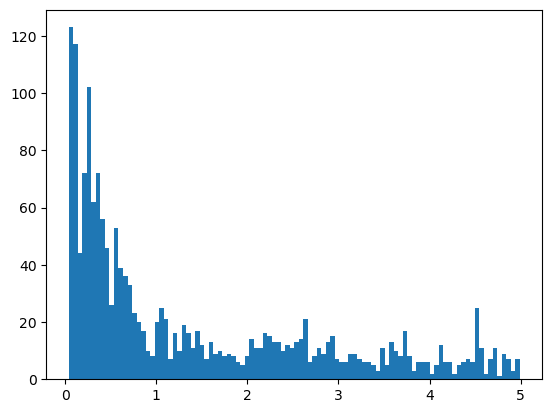

In [72]:
plt.hist(costs, bins = 100)

In [60]:
np.min(np.array(cost_dict.values()))

dict_values([np.float64(1.0745411815781332), np.float64(1.0846929284900244), np.float64(1.0938643590706219), np.float64(1.1010145899831767), np.float64(1.104766431518189), np.float64(1.1033307892658286), np.float64(1.094433042954159), np.float64(1.075259675578595), np.float64(1.0424592886570314), np.float64(0.992256647670223), np.float64(0.2258857740292469), np.float64(0.23727039422765245), np.float64(0.24997515737832543), np.float64(0.2638894030843308), np.float64(0.27876274914185045), np.float64(0.2941347817360053), np.float64(0.30924106392512657), np.float64(0.3228952191774698), np.float64(0.3333563013202492), np.float64(0.12244224681790247), np.float64(0.11672703452456681), np.float64(0.11026619515022898), np.float64(0.10311161912731512), np.float64(0.09537374805811977), np.float64(0.08724384070927327), np.float64(0.07901797815233862), np.float64(0.07111587660522205), np.float64(0.06407927278204449), np.float64(0.7184459438494274), np.float64(0.7209534241219079), np.float64(0.72331

In [21]:
np.sum(np.array(costs) < 0.02)

np.int64(23)

In [56]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fabiano/Research/git/ecodyn/lib_ecofun.py'>

In [26]:
np.array(cost_dict.values())

array(dict_values([np.float64(0.01799446062593051), np.float64(0.019541947264226204), np.float64(0.01673117534585568), np.float64(0.017678317239293764), np.float64(0.019913381129684396), np.float64(0.01685692942263505), np.float64(0.018958375460906257), np.float64(0.018831357636130145), np.float64(0.01841265523185107), np.float64(0.01801203597634168), np.float64(0.017631428217093407), np.float64(0.01727552194283219), np.float64(0.019927215991788982), np.float64(0.01695422541629736), np.float64(0.019384496144601002), np.float64(0.01668727324149715), np.float64(0.01908746076766675), np.float64(0.016512513435990372), np.float64(0.01915941624506458), np.float64(0.01649882090843843), np.float64(0.019721729375756256), np.float64(0.01675642251980531), np.float64(0.0190852938846564)]),
      dtype=object)

In [38]:
if not resu.success: print ('bau')

bau


r_inv 0.1
eta_g 0.2
eta_f 0.2
True
0.04680828322975321


[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

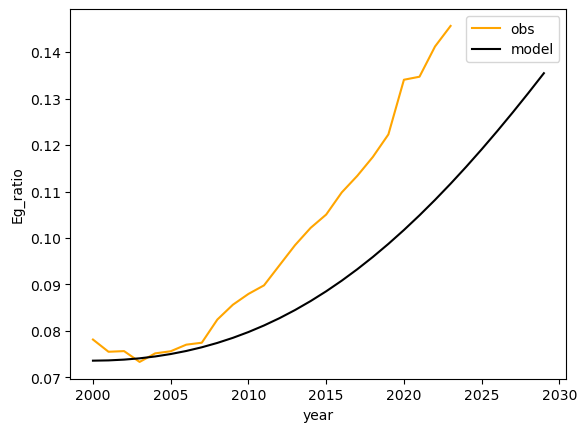

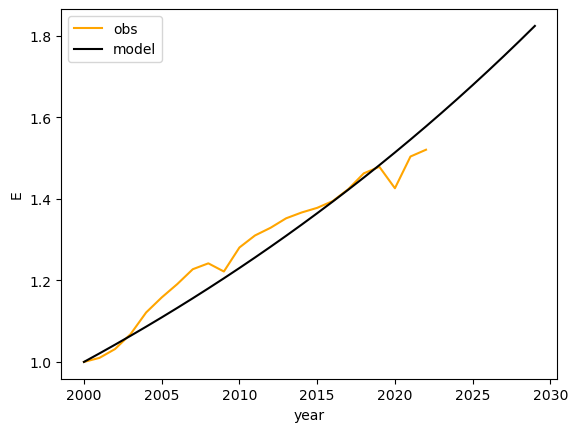

In [ ]:
vals = (0.45, 0.9, 0.35)

for par, parval in zip(pars, vals):
    print(par, parval)
    params[par] = parval

resu = lef.run_model(inicond = inicond, params = params, n_iter = 30, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=False, mu_state_scenario=mu_scen)
cos = lef.costfun(resu, obs)
print(resu.success)

print(cos)
lef.plot_resuvsobs_ds(resu, obs)


(array([558., 359., 144.,  92., 103., 112.,  61.,  77.,  52.,  71.,  57.,
         48.,  62.,  42.,  56.,  46.,  40.,  39.,  37.,  36.,  31.,  37.,
         33.,  31.,  29.,  38.,  30.,  23.,  22.,  27.,  21.,  15.,  22.,
         19.,  28.,  19.,  21.,  24.,  31.,  35.,  34.,  30.,  32.,  43.,
         37.,  42.,  37.,  44.,  41.,  56.,  53.,  56.,  48.,  55.,  50.,
         51.,  43.,  46.,  45.,  39.,  37.,  43.,  33.,  34.,  47.,  29.,
         37.,  31.,  36.,  29.,  26.,  22.,  22.,  13.,  12.,  20.,  11.,
         11.,  12.,   7.,  15.,   6.,   4.,   8.,   6.,   7.,   3.,   6.,
          2.,   5.,   3.,   2.,   2.,   1.,   0.,   1.,   1.,   0.,   0.,
          2.]),
 array([0.01649882, 0.06879269, 0.12108657, 0.17338044, 0.22567431,
        0.27796819, 0.33026206, 0.38255593, 0.4348498 , 0.48714368,
        0.53943755, 0.59173142, 0.6440253 , 0.69631917, 0.74861304,
        0.80090691, 0.85320079, 0.90549466, 0.95778853, 1.01008241,
        1.06237628, 1.11467015, 1.16696402, 1.

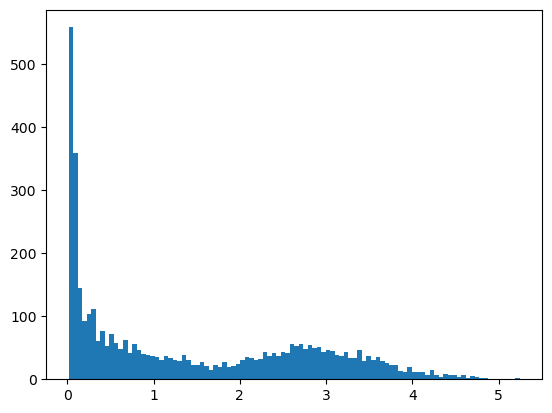

In [12]:
plt.hist(costs, bins = 100)

In [ ]:
lef.plot_resu(resu_om, year_ini = year_ini)